In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

In [2]:
df = pd.read_excel("Binary_Logistic_Regression_Student_Dataset_160.xlsx")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumn Names:", df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
   Study_Hours  Attendance  Assignment  Mid  Lab  Pass
0            7          56           5   18    6     0
1            4          58           6   12    8     0
2            5          57           8    8    4     0
3            7          61           3   15    9     0
4            3          83           6   19    7     1

Dataset Shape: (160, 6)

Column Names: ['Study_Hours', 'Attendance', 'Assignment', 'Mid', 'Lab', 'Pass']

Data Types:
Study_Hours    int64
Attendance     int64
Assignment     int64
Mid            int64
Lab            int64
Pass           int64
dtype: object

Missing Values:
Study_Hours    0
Attendance     0
Assignment     0
Mid            0
Lab            0
Pass           0
dtype: int64


In [3]:
X = df[['Study_Hours', 'Attendance', 'Assignment', 'Mid', 'Lab']]
y = df['Pass']

print("Features X shape:", X.shape)
print("Target y shape:", y.shape)

print("\nFirst 5 rows of X:")
print(X.head())

print("\nFirst 5 values of y:")
print(y.head())

Features X shape: (160, 5)
Target y shape: (160,)

First 5 rows of X:
   Study_Hours  Attendance  Assignment  Mid  Lab
0            7          56           5   18    6
1            4          58           6   12    8
2            5          57           8    8    4
3            7          61           3   15    9
4            3          83           6   19    7

First 5 values of y:
0    0
1    0
2    0
3    0
4    1
Name: Pass, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 128
Testing set size: 32


In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Model Coefficients:")
print(coef_df)

print("\nModel Intercept:", model.intercept_[0])

print("\n Feature contributing MOST to PASS:", coef_df.iloc[0]['Feature'])

Model Coefficients:
       Feature  Coefficient
2   Assignment     1.920422
4          Lab     1.744118
0  Study_Hours     1.467737
3          Mid     0.779410
1   Attendance     0.213086

Model Intercept: -56.77583573062668

 Feature contributing MOST to PASS: Assignment


In [6]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
print("Predicted vs Actual (first 20 rows):")
print(comparison.head(20))

correct = (y_pred == y_test.values).sum()
print(f"\nNumber of Correct Predictions: {correct} / {len(y_test)}")

Predicted vs Actual (first 20 rows):
    Actual  Predicted
0        1          1
1        0          0
2        1          1
3        0          0
4        0          0
5        0          0
6        1          1
7        1          1
8        1          1
9        1          1
10       0          0
11       1          1
12       0          0
13       0          0
14       0          0
15       1          1
16       0          0
17       1          1
18       0          0
19       1          1

Number of Correct Predictions: 31 / 32


Accuracy  : 0.9688
Precision : 0.9333
Recall    : 1.0000

Confusion Matrix:
[[17  1]
 [ 0 14]]

  True Positive  (Correctly predicted PASS) : 14
  True Negative  (Correctly predicted FAIL) : 17
  False Positive (Predicted PASS, Actually FAIL): 1
  False Negative (Predicted FAIL, Actually PASS): 0


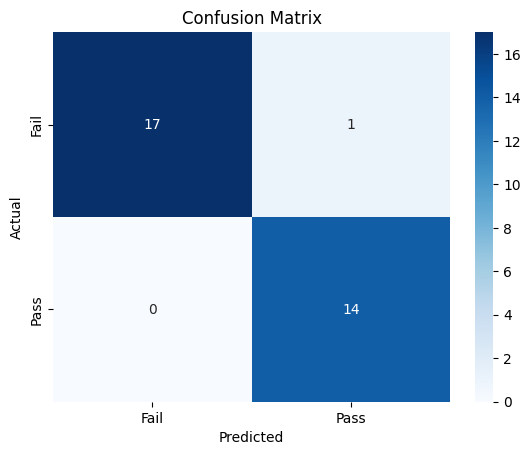


Model is better at predicting FAIL (higher recall)


In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")

print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()
print(f"\n  True Positive  (Correctly predicted PASS) : {tp}")
print(f"  True Negative  (Correctly predicted FAIL) : {tn}")
print(f"  False Positive (Predicted PASS, Actually FAIL): {fp}")
print(f"  False Negative (Predicted FAIL, Actually PASS): {fn}")

# Visualize
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fail','Pass'], yticklabels=['Fail','Pass'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

if precision > recall:
    print("\nModel is better at predicting PASS (higher precision)")
else:
    print("\nModel is better at predicting FAIL (higher recall)")

In [10]:
new_students = pd.DataFrame({
    'Study_Hours': [4, 2, 7],
    'Attendance':  [70, 55, 85],
    'Assignment':  [6, 4, 8],
    'Mid':         [15, 10, 22],
    'Lab':         [7, 5, 9]
})

predictions = model.predict(new_students)
probabilities = model.predict_proba(new_students)

for i in range(3):
    label = "PASS" if predictions[i] == 1 else "FAIL"
    prob_pass = probabilities[i][1]
    prob_fail = probabilities[i][0]
    print(f"--- Student {i+1} ---")
    print(f"  Prediction  : {label}")
    print(f"  Probability : PASS={prob_pass:.2%}, FAIL={prob_fail:.2%}")
    print(f"  Interpretation: {'High chance of passing.' if prob_pass >= 0.7 else 'At risk of failing.' if prob_pass < 0.5 else 'Borderline case.'}\n")

--- Student 1 ---
  Prediction  : FAIL
  Probability : PASS=36.21%, FAIL=63.79%
  Interpretation: At risk of failing.

--- Student 2 ---
  Prediction  : FAIL
  Probability : PASS=0.00%, FAIL=100.00%
  Interpretation: At risk of failing.

--- Student 3 ---
  Prediction  : PASS
  Probability : PASS=100.00%, FAIL=0.00%
  Interpretation: High chance of passing.



Feature Importance (by Coefficient):
       Feature  Coefficient
0   Assignment     1.920422
1          Lab     1.744118
2  Study_Hours     1.467737
3          Mid     0.779410
4   Attendance     0.213086

 Most Influential Feature  : Assignment
Least Influential Feature : Attendance


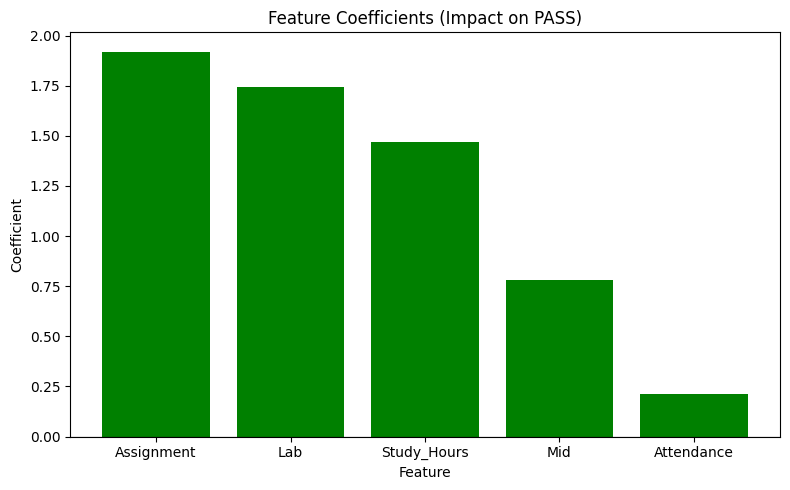

In [11]:
coef_df_sorted = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print("Feature Importance (by Coefficient):")
print(coef_df_sorted)

most_influential  = coef_df_sorted.iloc[0]['Feature']
least_influential = coef_df_sorted.iloc[-1]['Feature']

print(f"\n Most Influential Feature  : {most_influential}")
print(f"Least Influential Feature : {least_influential}")

# Bar chart
plt.figure(figsize=(8, 5))
colors = ['green' if c > 0 else 'red' for c in coef_df_sorted['Coefficient']]
plt.bar(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Feature Coefficients (Impact on PASS)")
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.tight_layout()
plt.show()

In [13]:
y_prob = model.predict_proba(X_test)[:, 1]

# Default threshold: 0.5
y_pred_05 = (y_prob >= 0.5).astype(int)

# New threshold: 0.6
y_pred_06 = (y_prob >= 0.6).astype(int)

acc_05 = accuracy_score(y_test, y_pred_05)
acc_06 = accuracy_score(y_test, y_pred_06)

cm_05 = confusion_matrix(y_test, y_pred_05)
cm_06 = confusion_matrix(y_test, y_pred_06)

tn0, fp0, fn0, tp0 = cm_05.ravel()
tn1, fp1, fn1, tp1 = cm_06.ravel()

print(f"{'Metric':<25} {'Threshold=0.5':>15} {'Threshold=0.6':>15}")
print("-" * 57)
print(f"{'Accuracy':<25} {acc_05:>15.4f} {acc_06:>15.4f}")
print(f"{'True Positive':<25} {tp0:>15} {tp1:>15}")
print(f"{'True Negative':<25} {tn0:>15} {tn1:>15}")
print(f"{'False Positive':<25} {fp0:>15} {fp1:>15}")
print(f"{'False Negative':<25} {fn0:>15} {fn1:>15}")

print("\n📊 Analysis:")
print(f"  Accuracy {'increased ' if acc_06 > acc_05 else 'decreased'} with threshold 0.6")
print(f"  False Positives {'reduced ' if fp1 < fp0 else 'did not reduce'} ({fp0} → {fp1})")
print(f"  False Negatives {'increased ' if fn1 > fn0 else 'did not increase'} ({fn0} → {fn1})")

Metric                      Threshold=0.5   Threshold=0.6
---------------------------------------------------------
Accuracy                           0.9688          0.9688
True Positive                          14              14
True Negative                          17              17
False Positive                          1               1
False Negative                          0               0

📊 Analysis:
  Accuracy decreased with threshold 0.6
  False Positives did not reduce (1 → 1)
  False Negatives did not increase (0 → 0)
